# Task 3 — Tabular / Clinical Data Model (XGBoost)
**COMP41840 AI for Health**  
**Owner:** Liban  
**Goal:** Binary classification — benign vs malignant — from clinical/genomic tabular features


In [1]:
# Colab setup: run once per fresh runtime
!pip -q install xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score
)
from sklearn.impute import SimpleImputer

import xgboost as xgb
import joblib

sns.set_theme(style='whitegrid')
SEED = 42
DATA_ROOT = Path('../data/raw')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)

_SRC = Path('../src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))
from patient_split import (
    kaggle_multimodal_available,
    build_aligned_manifest,
    assign_split_manifest,
    save_patient_split,
    sort_test_by_patient,
)
USE_ALIGNED = kaggle_multimodal_available(DATA_ROOT)
print('Aligned multi-modal (shared split):', USE_ALIGNED)

Aligned multi-modal (shared split): True


## 3.1 — Load & Inspect Clinical Data

In [3]:
manifest = build_aligned_manifest(DATA_ROOT)
manifest = assign_split_manifest(manifest, SEED)
save_patient_split(manifest, RESULTS_DIR)
train_df = manifest.loc[manifest['split'] == 'train'].copy()
val_df = manifest.loc[manifest['split'] == 'val'].copy()
test_df = manifest.loc[manifest['split'] == 'test'].copy()
class_names = ['benign', 'malignant']
print('Loaded: Kaggle patient_history + molecular (aligned with ultrasound)')
print('Patients:', len(manifest), '| Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))
print(manifest.head())


Loaded: Kaggle patient_history + molecular (aligned with ultrasound)
Patients: 647 | Train: 452 Val: 97 Test: 98
  Patient ID  Age at Diagnosis Type of Breast Surgery  Cohort  \
0    MB-0002             43.19      Breast Conserving     1.0   
1    MB-0008             76.97             Mastectomy     1.0   
2    MB-0010             78.77             Mastectomy     1.0   
3    MB-0028             86.41      Breast Conserving     1.0   
4    MB-0035             84.22             Mastectomy     1.0   

  ER status measured by IHC ER Status  Neoplasm Histologic Grade  \
0                   Positve  Positive                        3.0   
1                   Positve  Positive                        3.0   
2                   Positve  Positive                        3.0   
3                   Positve  Positive                        3.0   
4                  Negative  Positive                        2.0   

  HER2 status measured by SNP6 HER2 Status Tumor Other Histologic Subtype  \
0         

In [4]:
if not USE_ALIGNED:
    # Support both expected schemas:
    # - image-linked table with string labels in `label` (benign/malignant)
    # - clinical survival table with binary target in `Event` (0/1)
    if 'label' in df.columns:
        df_binary = df[df['label'].isin(['benign', 'malignant'])].copy()
        df_binary['label_enc'] = (df_binary['label'] == 'malignant').astype(int)
        class_names = ['benign', 'malignant']
    elif 'Event' in df.columns:
        df_binary = df.copy()
        df_binary['label_enc'] = pd.to_numeric(df_binary['Event'], errors='coerce').fillna(0).astype(int)
        df_binary = df_binary[df_binary['label_enc'].isin([0, 1])].copy()
        df_binary['label'] = df_binary['label_enc'].map({0: 'negative', 1: 'positive'})
        class_names = ['negative', 'positive']
    else:
        raise ValueError("No supported target column found. Expected 'label' or 'Event'.")

    print('Class counts:')
    print(df_binary['label'].value_counts())

## 3.2 — Feature Engineering & Preprocessing

In [5]:
TARGET = 'label_enc'
DROP_COLS = {
    'label', 'label_enc', 'Event', 'split', 'image_path', 'class',
    'patient_id', 'PatientID', 'Patient ID', "Patient's Vital Status",
}
# Post-treatment / outcome proxies — drop for leakage-free tabular scores (re-run 03 then 04).
LEAKAGE_COLS = {
    'Overall Survival Status', 'Overall Survival (Months)',
    'Relapse Free Status', 'Relapse Free Status (Months)',
    'Chemotherapy', 'Hormone Therapy', 'Radio Therapy',
    'Type of Breast Surgery',
}

if USE_ALIGNED:
    feature_cols = [c for c in train_df.columns if c not in DROP_COLS and c not in LEAKAGE_COLS]
    X_train = train_df[feature_cols].copy()
    X_val = val_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[TARGET].values
    y_val = val_df[TARGET].values
    y_test = test_df[TARGET].values
    X_parts = pd.concat([X_train, X_val, X_test], axis=0)
    cat_cols = X_parts.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X_parts[col] = le.fit_transform(X_parts[col].astype(str))
    n1, n2, n3 = len(X_train), len(X_val), len(X_test)
    X_train = X_parts.iloc[:n1].reset_index(drop=True)
    X_val = X_parts.iloc[n1:n1 + n2].reset_index(drop=True)
    X_test = X_parts.iloc[n1 + n2:].reset_index(drop=True)
    X = manifest[feature_cols].copy()
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    y = manifest[TARGET].values
    test_patient_ids = test_df['patient_id'].astype(str).tolist()
else:
    feature_cols = [c for c in df_binary.columns if c not in DROP_COLS and c not in LEAKAGE_COLS]
    X = df_binary[feature_cols].copy()
    y = df_binary[TARGET].values
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    test_patient_ids = None

print(f'Features: {len(feature_cols)}  |  Samples (tabular matrix): {len(X)}')

Features: 24  |  Samples (tabular matrix): 647


/tmp/ipykernel_35243/2742767936.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_parts.select_dtypes(include='object').columns.tolist()


## 3.3 — Train/Val/Test Split

In [6]:
if not USE_ALIGNED:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 452  Val: 97  Test: 98


## 3.4 — XGBoost Model

In [7]:
# Compute class weight ratio for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_val_imp, y_val)],
    verbose=50
)

scale_pos_weight: 2.07
[0]	validation_0-logloss:0.66108
[50]	validation_0-logloss:0.29847
[96]	validation_0-logloss:0.27550


/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [19:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

## 3.5 — Test Set Evaluation

              precision    recall  f1-score   support

      benign       0.95      0.85      0.90        66
   malignant       0.74      0.91      0.82        32

    accuracy                           0.87        98
   macro avg       0.85      0.88      0.86        98
weighted avg       0.88      0.87      0.87        98

AUC-ROC: 0.9498


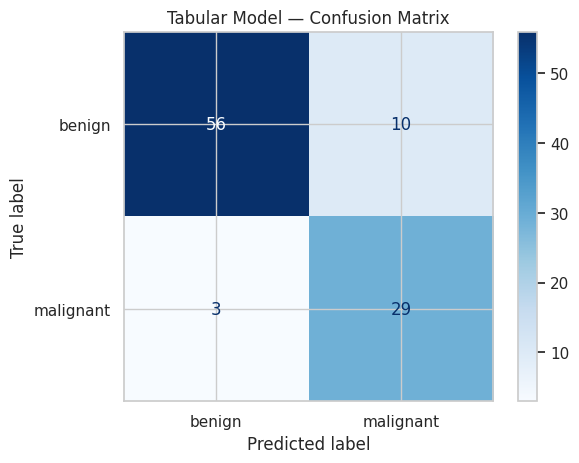

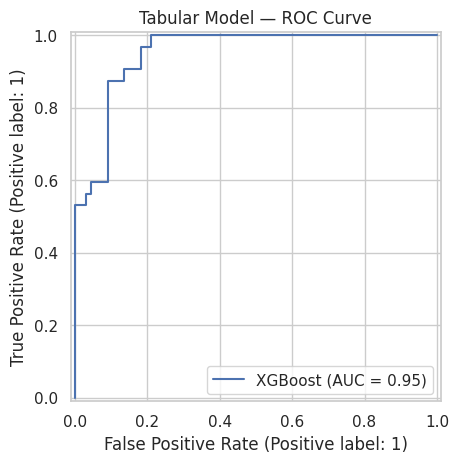

In [8]:
y_pred  = xgb_model.predict(X_test_imp)
y_proba = xgb_model.predict_proba(X_test_imp)[:, 1]

report_txt = classification_report(y_test, y_pred, target_names=class_names)
print(report_txt)
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

(RESULTS_DIR / 'tabular_classification_report.txt').write_text(report_txt)

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=class_names
).plot(cmap='Blues')
plt.title('Tabular Model — Confusion Matrix')
plt.savefig(RESULTS_DIR / 'figures/tabular_confusion_matrix.png', dpi=150)
plt.show()

# ROC
RocCurveDisplay.from_predictions(y_test, y_proba, name='XGBoost')
plt.title('Tabular Model — ROC Curve')
plt.savefig(RESULTS_DIR / 'figures/tabular_roc.png', dpi=150)
plt.show()

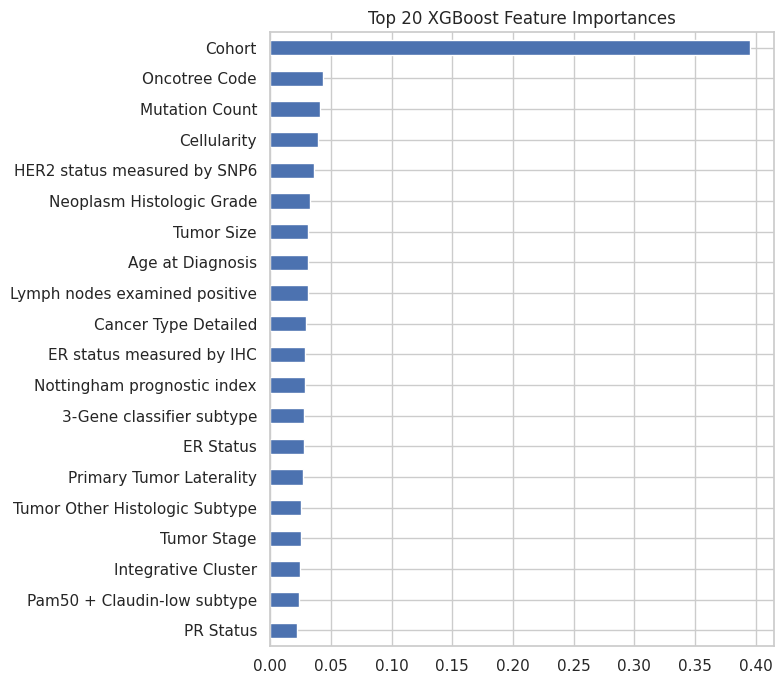

In [9]:
# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi.tail(20).plot(kind='barh', figsize=(8, 7), title='Top 20 XGBoost Feature Importances')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/tabular_feature_importance.png', dpi=150)
plt.show()

In [10]:
# Save probs/preds for fusion (same patient order as Task 2 when USE_ALIGNED)
if test_patient_ids is not None:
    y_proba, y_pred, y_test, test_patient_ids = sort_test_by_patient(
        test_patient_ids, y_proba, y_pred, y_test
    )
np.save(RESULTS_DIR / 'tabular_test_probs.npy',  y_proba)
np.save(RESULTS_DIR / 'tabular_test_labels.npy', y_test)
if test_patient_ids is not None:
    np.save(RESULTS_DIR / 'test_patient_ids.npy', np.array(test_patient_ids, dtype=object))

tabular_metrics = {
    'auc':       round(roc_auc_score(y_test, y_proba), 4),
    'precision': round(precision_score(y_test, y_pred), 4),
    'recall':    round(recall_score(y_test, y_pred), 4),
    'f1':        round(f1_score(y_test, y_pred), 4),
}

metrics_path = RESULTS_DIR / 'metrics.json'
existing = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}
existing['tabular'] = tabular_metrics
metrics_path.write_text(json.dumps(existing, indent=2))
xgb_model.save_model(str(RESULTS_DIR / 'tabular_xgb_model.json'))
joblib.dump(
    {
        'imputer': imputer,
        'feature_cols': feature_cols,
        'USE_ALIGNED': USE_ALIGNED,
        'X_train_imp': X_train_imp,
        'X_val_imp': X_val_imp,
        'X_test_imp': X_test_imp,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    },
    RESULTS_DIR / 'tabular_preprocess.joblib',
)
print('Saved:', tabular_metrics)
print('Also saved tabular_xgb_model.json + tabular_preprocess.joblib for Task 5 (SHAP).')

Saved: {'auc': 0.9498, 'precision': 0.7436, 'recall': 0.9062, 'f1': 0.8169}
Also saved tabular_xgb_model.json + tabular_preprocess.joblib for Task 5 (SHAP).


## 3.6 — Cross-Validation (robustness check)

In [11]:
X_all = imputer.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Simpler model for CV speed
cv_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='logloss', random_state=SEED
)

cv_scores = cross_val_score(cv_model, X_all, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:58:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:58:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:58:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5-Fold CV AUC: 0.9308 ± 0.0082


/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:58:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mrquorr/.pyenv/versions/3.12.8/envs/health/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:58:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
